[2026-08-04 19:12:43] [info     ] 计算VWAP+ADRC因子(v2)，区间: 2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-04 19:13:01] [info     ] 完成，共 242000 行
[2026-08-04 19:13:01] [info     ] 读取因子库，区间: 2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-04 19:13:04] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-04 19:13:05] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-04 19:13:05] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-04 19:13:05] [info     ] ========== 数据检查 ==========
[2026-08-04 19:13:05] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', '

时段,IC
2024-01-15~2024-02-08,0.0082
2024-09-24~2024-10-08,0.0703

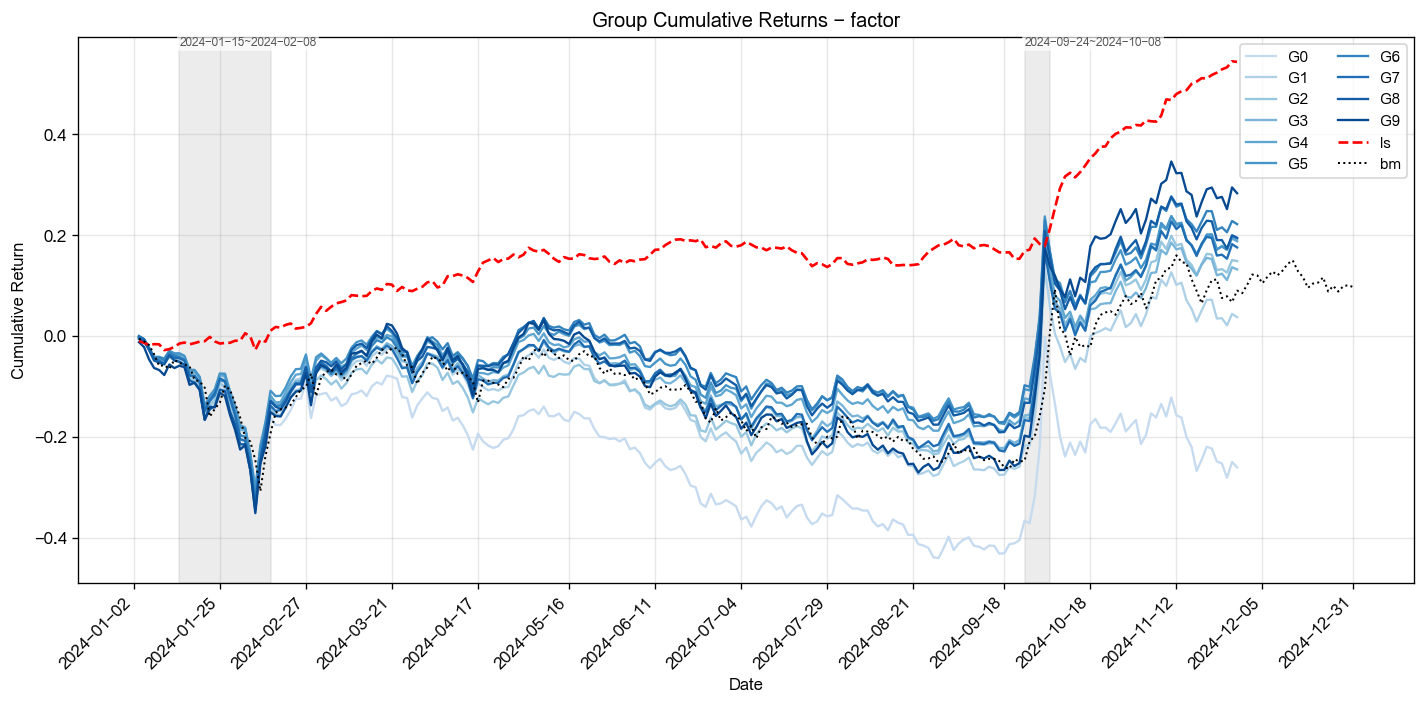
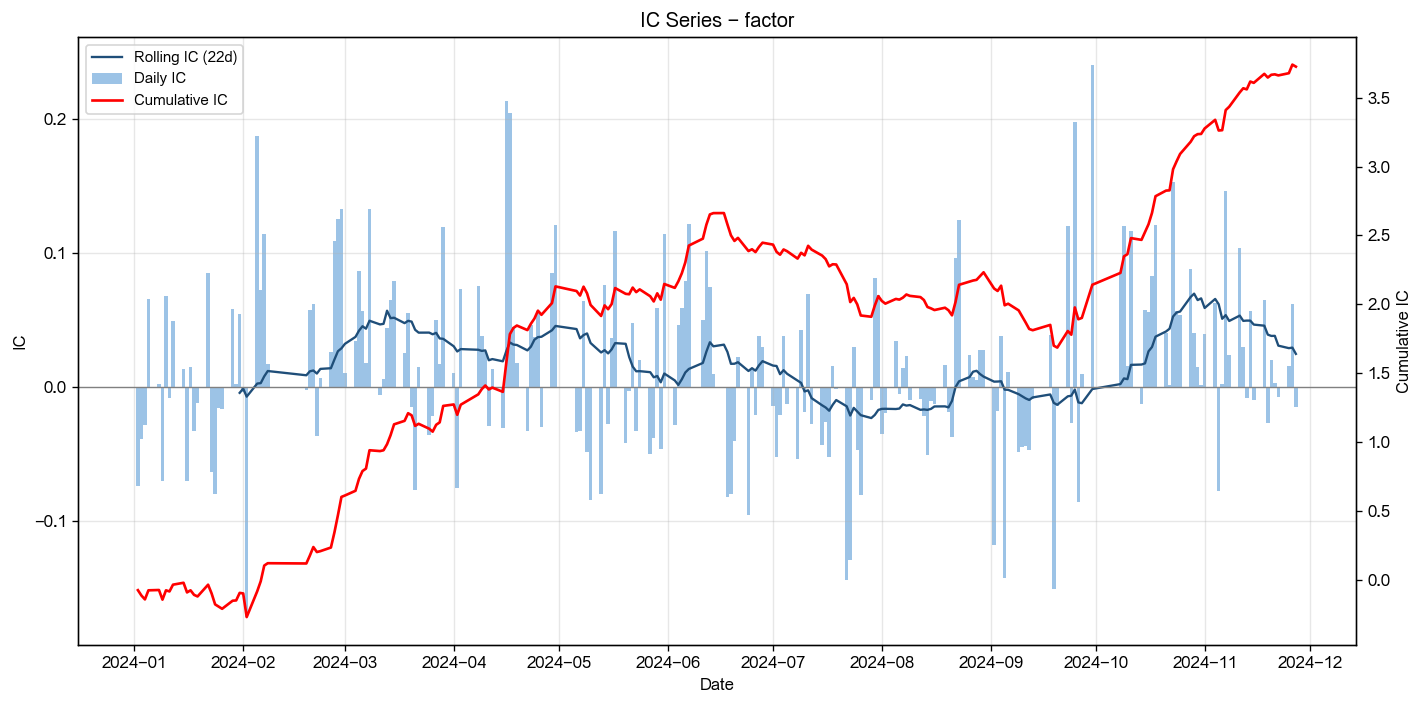
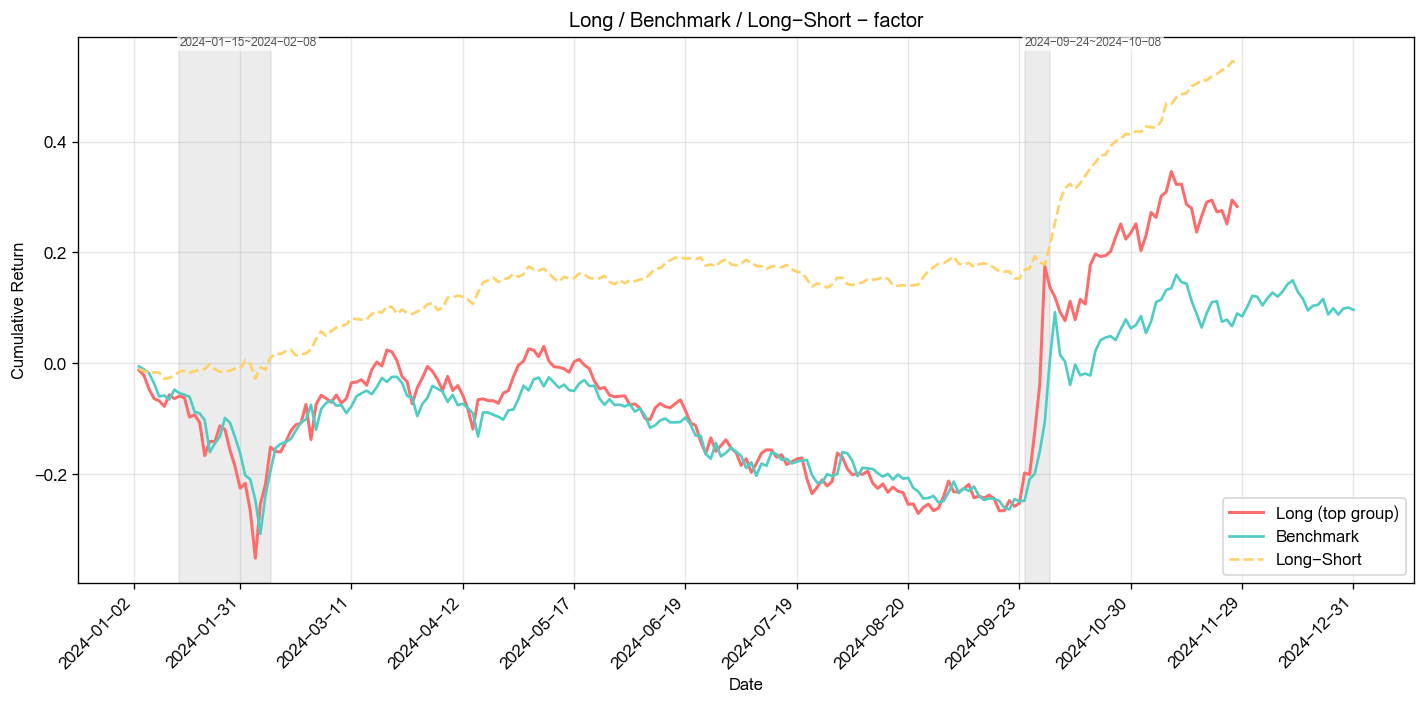
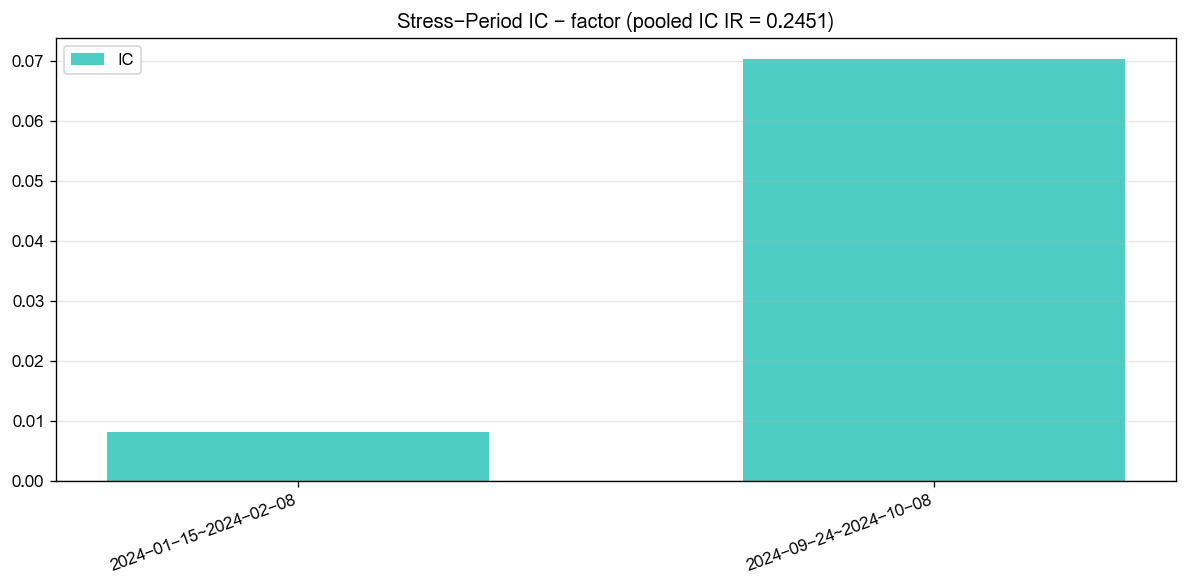
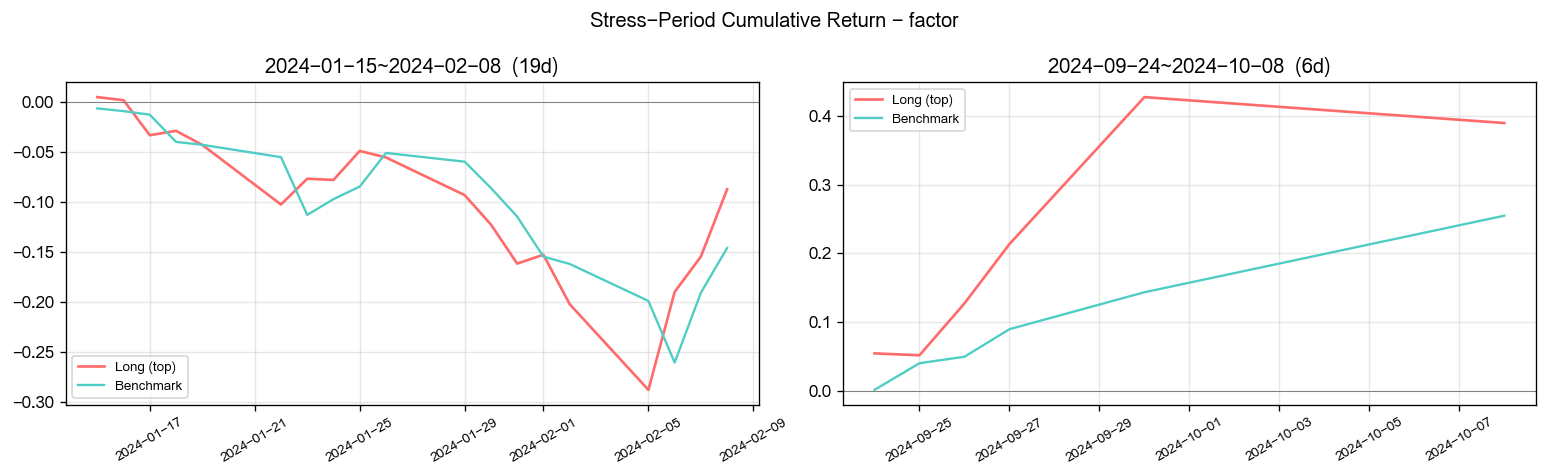

[2026-08-04 19:15:05] [info     ] ========== 因子池回归 ==========
[2026-08-04 19:15:05] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-04 19:15:09] [info     ] 获取收益率数据, 耗时: 3.9979 秒
[2026-08-04 19:15:11] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.6649 秒
[2026-08-04 19:15:11] [info     ] 统计 回归结果, 耗时: 0.0123 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.4880,0.0309,0.0124,1.0000
2,cci_14,2.1656,0.0354,0.0164,1.0000
3,rsi_12,2.0607,0.0434,0.0210,1.0000
4,amount,1.8548,0.0195,0.0105,1.0000
5,gross_profit_rate_ttm,1.5425,0.0068,0.0044,1.0000
6,netflow_amount_main,1.5095,0.0254,0.0168,1.0000
7,net_profit_rate_ttm,1.4328,0.0040,0.0028,0.8000
8,bias_20,1.4131,0.0286,0.0203,0.9000
9,pb,1.3904,0.0097,0.0070,0.9000
10,netflow_amount_rate_main,1.3529,0.0101,0.0074,1.0000

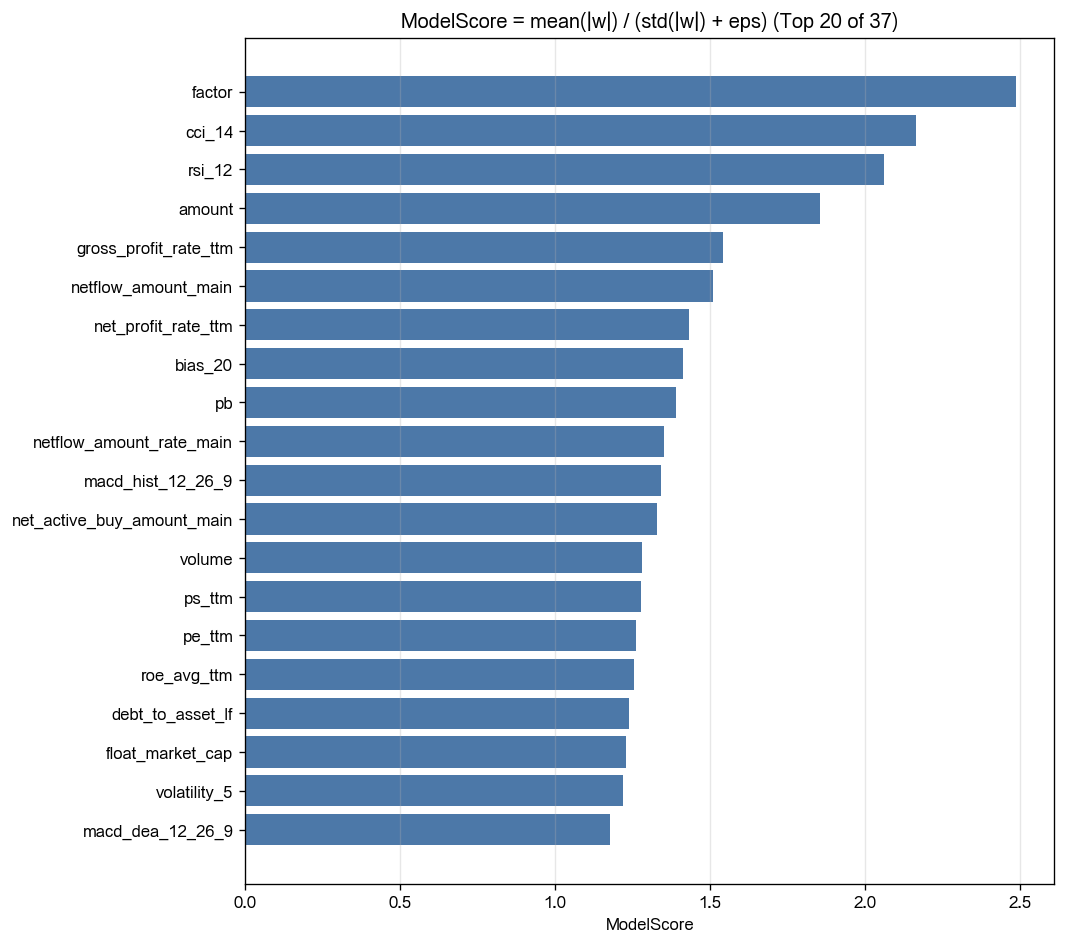
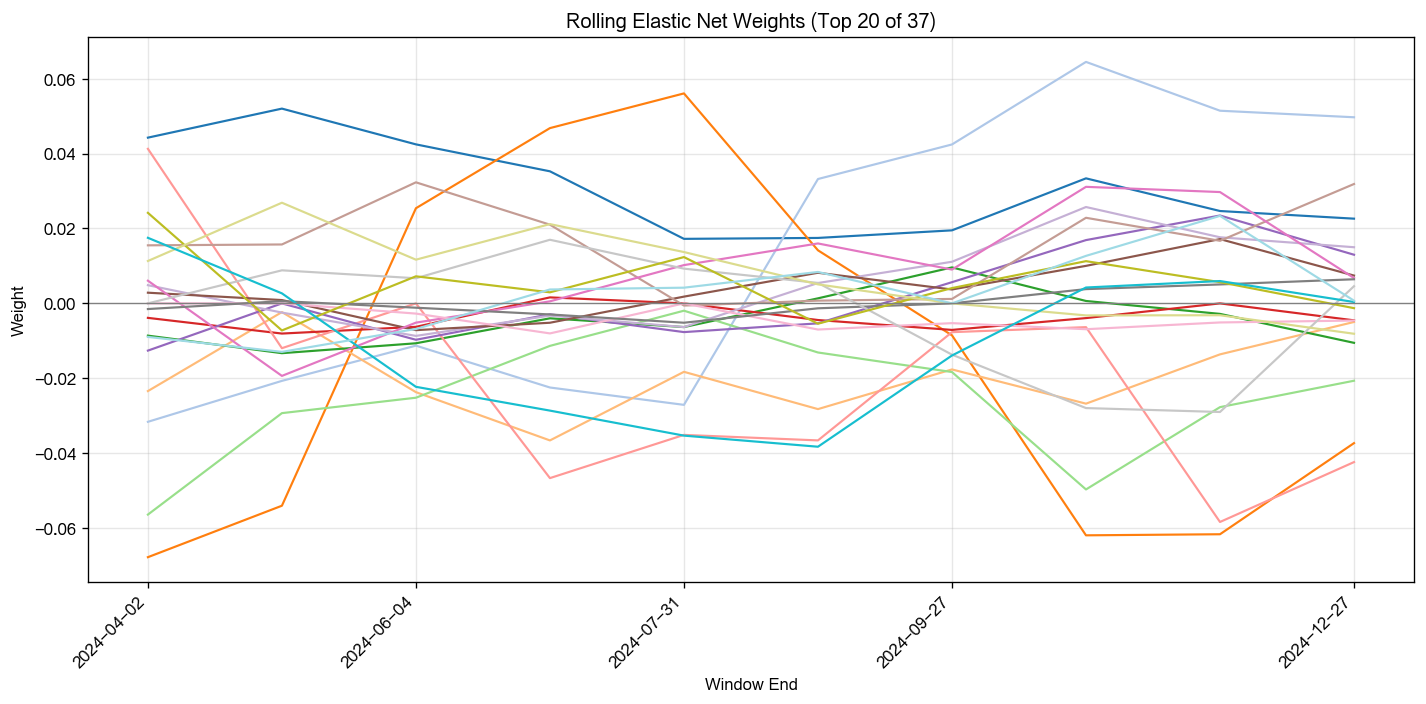
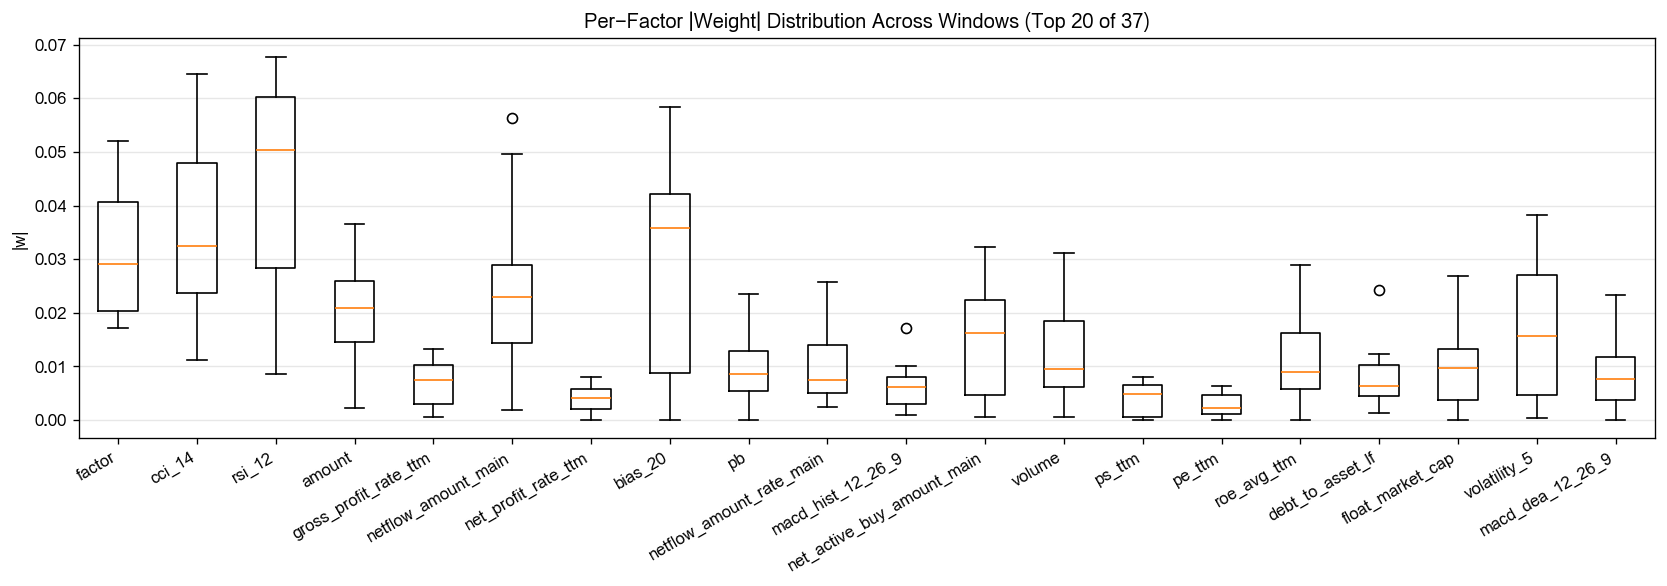
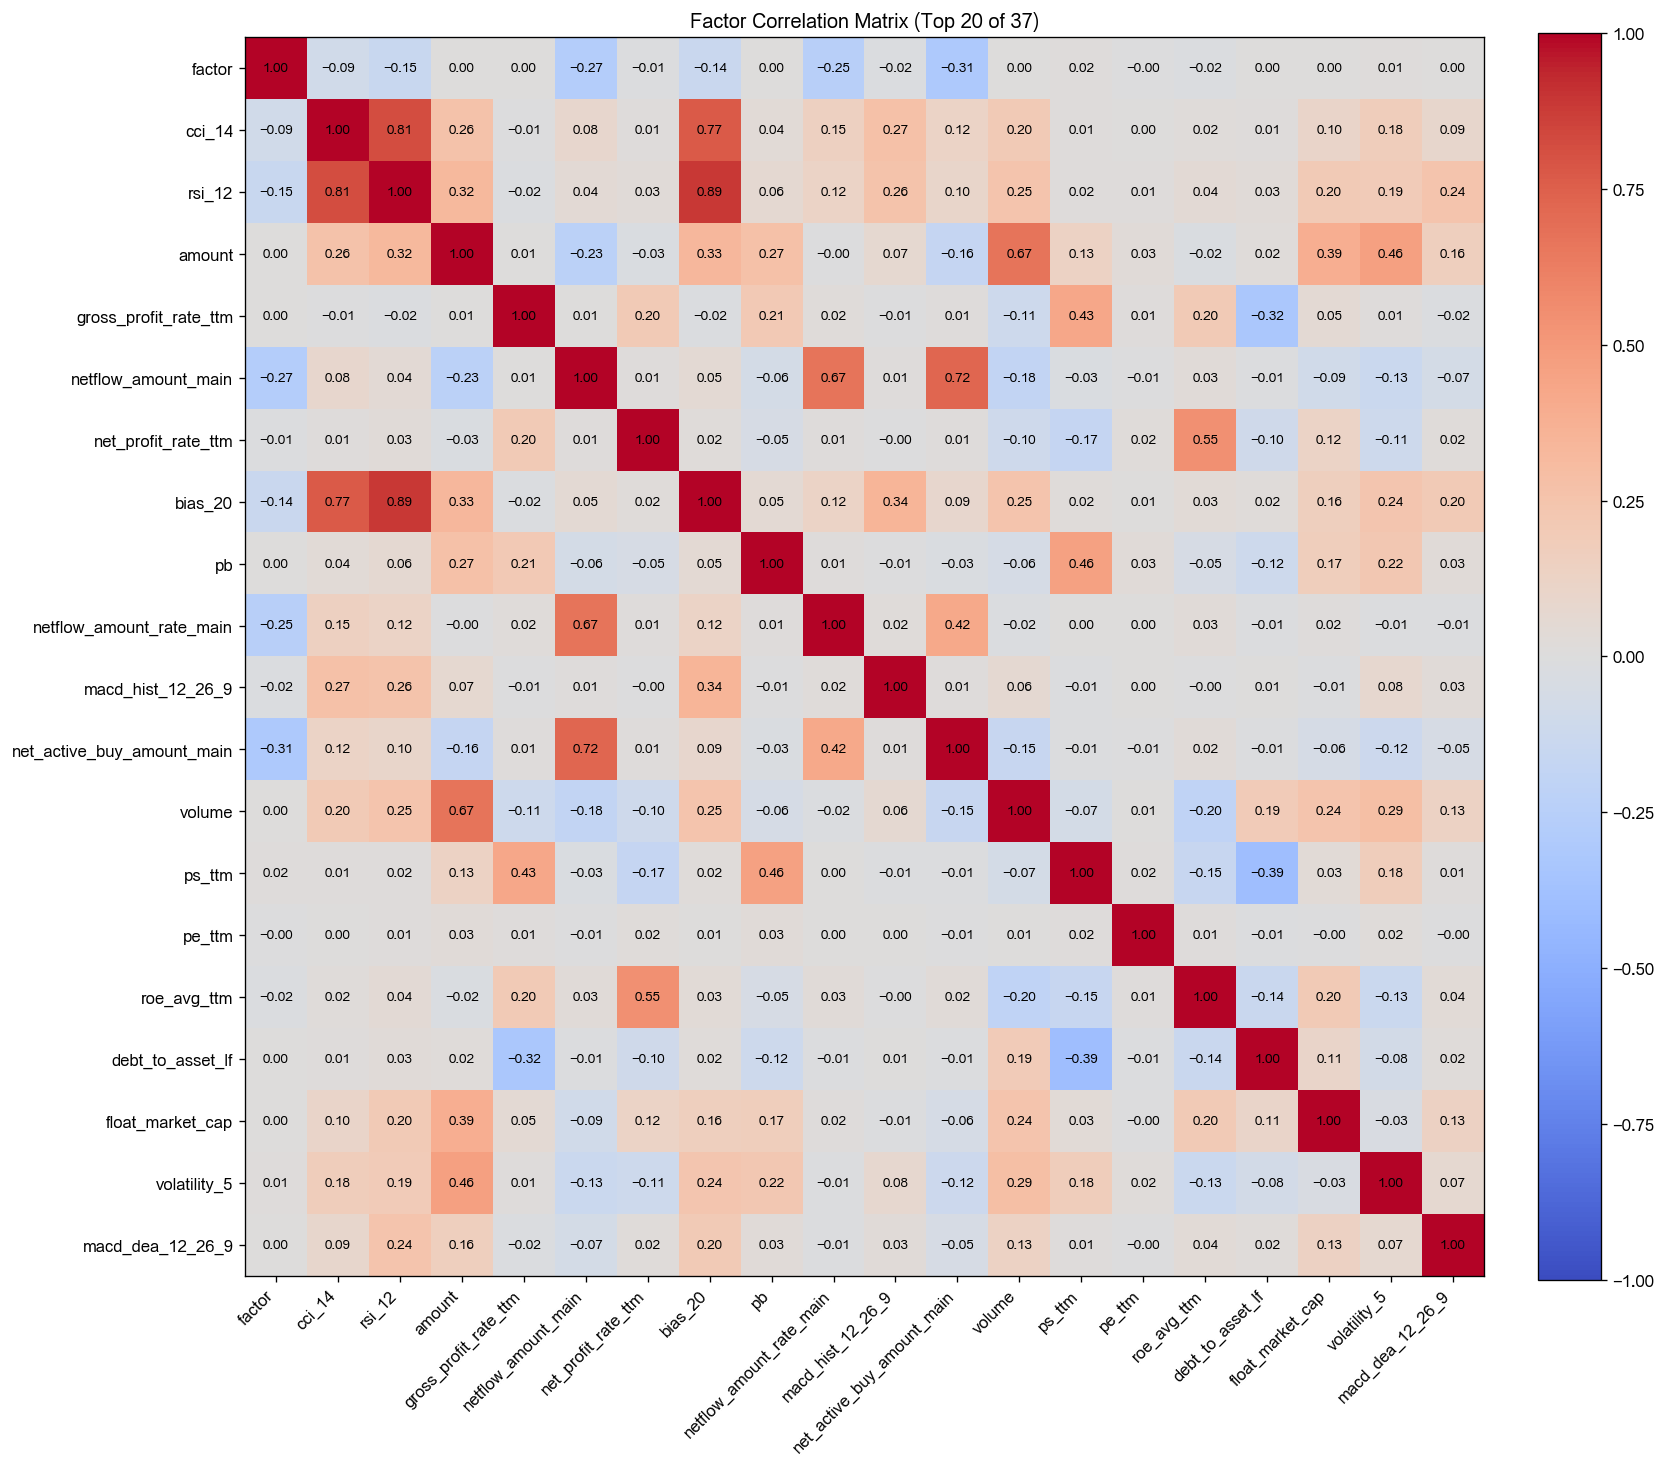

[2026-08-04 19:15:15] [warning  ] 返回的Outputs实例(size=35335721) 大于 64K, 将不会被缓存
[2026-08-04 19:15:15] [info     ] bigalpha_eval.v4 运行完成 [130.835s].


In [1]:
import dai
import pandas as pd
import numpy as np


def main(datasources, start_date, end_date):
    """
    VWAP偏差因子 + ADRC扰动补偿（量价因子版 v2）
    
    ====== 修改要点 ======
    1. 因子方向反转：用 (vwap - close)/close 代替 close/vwap
       原因子IC=-0.0133（负向），反转后预期IC>0
    2. ADRC补偿重构：用向量化ESO替代简单rolling_std
       z1=EMA跟踪信号, z3=扰动估计, factor=raw - k*z3
    3. 横截面z-score标准化：消除个股间尺度差异
    4. 去极值处理：winsorize裁剪异常值
    """

    bar_table = datasources["bar1m"]

    # ===== 向前扩查询窗口，给ADRC的滚动窗口留足历史 =====
    BUFFER_DAYS = 60
    query_start = (pd.to_datetime(start_date) - pd.Timedelta(days=BUFFER_DAYS)
                   ).strftime('%Y-%m-%d %H:%M:%S')

    sql = f"""
    SELECT
        date::DATE::DATETIME AS date,
        instrument,
        LAST(close ORDER BY date) AS daily_close,
        SUM(volume) AS daily_volume,
        SUM(amount) AS daily_amount
    FROM {bar_table}
    GROUP BY date::DATE, instrument
    """

    df = dai.query(sql, filters={'date': [query_start, end_date]}).df()

    # 转成float，防止Decimal类型报错
    df['daily_close'] = df['daily_close'].astype(float)
    df['daily_volume'] = df['daily_volume'].astype(float)
    df['daily_amount'] = df['daily_amount'].astype(float)
    df['date'] = pd.to_datetime(df['date'])

    df = df.sort_values(['instrument', 'date'])

    # ===== 修改1：VWAP偏差因子（反转方向）=====
    # 原代码：factor = close / vwap
    #   >1 表示收盘价高于VWAP（尾盘拉升），IC为负→预测下跌
    # 修改后：factor = (vwap - close) / close
    #   >0 表示VWAP高于收盘价（盘中被压低，有反弹空间）→预测上涨
    df['vwap'] = df['daily_amount'] / df['daily_volume']
    df['raw_factor'] = (df['vwap'] - df['daily_close']) / df['daily_close']

    # 清理无效值
    df = df.dropna(subset=['raw_factor'])
    df = df[df['raw_factor'] != float('inf')]
    df = df[df['raw_factor'] != float('-inf')]

    # ===== 修改2：ADRC风格的扰动补偿（向量化ESO）=====
    # 原代码：z3 = rolling_std, factor = factor / (1 + z3)
    #   问题：std只是波动率，不是扰动估计；除法会放大噪声
    #
    # 改进：向量化ESO近似
    #   z1 = EMA(raw_factor, span=5)  → 跟踪信号（ESO第一状态）
    #   disturbance = raw_factor - z1  → 瞬时扰动
    #   z3 = EMA(disturbance, span=10) → 扰动估计（ESO第三状态）
    #   factor = raw_factor - 0.3 * z3  → 补偿后的因子
    #
    # 参数含义：
    #   span=5 对应 ESO 的 beta1（快速跟踪）
    #   span=10 对应 ESO 的 beta3（慢速扰动估计）
    #   0.3 是补偿系数（类似NLSEF增益）

    df['z1'] = df.groupby('instrument')['raw_factor'].transform(
        lambda x: x.ewm(span=5, adjust=False).mean()
    )
    df['disturbance'] = df['raw_factor'] - df['z1']
    df['z3'] = df.groupby('instrument')['disturbance'].transform(
        lambda x: x.ewm(span=10, adjust=False).mean()
    )
    # 补偿：从原始因子中减去估计的扰动
    df['factor'] = df['raw_factor'] - 0.3 * df['z3']

    # ===== 修改3：去极值（Winsorize）=====
    # 裁剪前后1%的极端值，防止异常值干扰因子评价
    def winsorize_group(x):
        q01 = x.quantile(0.01)
        q99 = x.quantile(0.99)
        return x.clip(q01, q99)

    df['factor'] = df.groupby('date')['factor'].transform(winsorize_group)

    # ===== 修改4：横截面z-score标准化 =====
    # 每个交易日对所有股票做z-score，消除个股间尺度差异
    # 使得因子值在截面上均值为0、标准差为1
    df['factor'] = df.groupby('date')['factor'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

    # 清理
    df = df.dropna(subset=['factor'])
    df = df[df['factor'] != float('inf')]
    df = df[df['factor'] != float('-inf')]

    # ===== 算完因子后裁回真正的评估区间 =====
    df = df[(df['date'] >= pd.to_datetime(start_date)) &
            (df['date'] <= pd.to_datetime(end_date))]

    # ===== 对齐股票池 =====
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])

    df = pd.merge(df, stk_pool, how='right', on=['date', 'instrument'])

    df['date'] = pd.to_datetime(df['date'])
    df['factor'] = df['factor'].astype(float)

    return df[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import structlog
    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
    }
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算VWAP+ADRC因子(v2)，区间: {start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)
    logger.info(f"完成，共 {len(factor_data)} 行")

    logger.info(f"读取因子库，区间: {start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval.v4(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
